# Introduction to encoding models

This tutorial introduces linear encoding models in language neuroscience. You will learn how to build a model which uses stimulus features (LLM word embeddings) to predict speech-evoked neural activity (via ridge regression).

This tutorial draws upon the ["Podcast" ECoG dataset](https://www.nature.com/articles/s41597-025-05462-2), an open-source dataset of intracranial recordings in epilepy patients who listened to a 30-minute segment from the ["This American Life" Podcast](https://www.thisamericanlife.org/631/transcript). Handily, this dataset already comes with several pre-computed feature spaces (e.g., GPT2 word embeddings). For this tutorial, we will use word embeddings to predict neural activity at each electrode via an encoding model. Encoding models use linear regression to learn to map features onto brain activity. Here, we will use the [Himalaya](https://gallantlab.org/himalaya/index.html) Python package to fit encoding models using ridge regression.

**Acknowledgments:** This tutorial builds directly upon the encoding model notebook in the [Podcast ECoG Dataset Tutorials](https://github.com/hassonlab/podcast-ecog-tutorials) developed by members of the Hasson Lab at Princeton University.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bootstrapbill/encoding_model_tutorial/blob/main/notebooks/encoding_tutorial.ipynb)

**Note:** Before running the tutorial click 'Runtime' -> 'Change runtime type' -> 'T4 GPU' to switch from CPU to GPU for faster model fitting.


In [1]:
# Install required packages

!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124
!pip install mne mne_bids himalaya scikit-learn pandas matplotlib nilearn
!pip install wordfreq

Looking in indexes: https://download.pytorch.org/whl/cu124
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.1/183.1 kB 7.9 MB/s eta 0:00:00


In [2]:
# Import required packages

import mne
import h5py
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nilearn.plotting import plot_markers
from mne_bids import BIDSPath

from himalaya.backend import set_backend, get_backend
from himalaya.ridge import RidgeCV
from himalaya.scoring import correlation_score

from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

Let's set the [Himalaya backend](https://gallantlab.org/himalaya/_generated/himalaya.backend.set_backend.html#himalaya.backend.set_backend) to `torch_cuda` so we can utilize a GPU for training, if available. This will be much faster than using CPU.

In [3]:
if torch.cuda.is_available():
    set_backend("torch_cuda")
    print("Using cuda!")

Using cuda!


# Loading open-source datasets from OpenNeuro

We will load in the data for this tutorial from [OpenNeuro.org](https://openneuro.org/), an online data repository for neuroimaging experiments where the Podcast dataset is stored. Feel free to click through to OpenNeuro to explore the other datasets that are available!

## Load in language features (word embeddings)

Let's first load in the contextual word embeddings which the Hasson lab previously extracted from GPT2-xl. The loaded features should be a numpy array with the shape: number_of_tokens * feature_dimensions (for GPT2-xl there will be 1600 feature dimensions).

In [4]:
# download the word embeddings

embedding_path = f"stimuli/gpt2-xl/features.hdf5"
!wget -nc https://s3.amazonaws.com/openneuro.org/ds005574/$embedding_path
embedding_path = "features.hdf5"

print(f"Using embedding file path: {embedding_path}")

--2026-04-13 02:19:50--  https://s3.amazonaws.com/openneuro.org/ds005574/stimuli/gpt2-xl/features.hdf5
Resolving s3.amazonaws.com (s3.amazonaws.com)... 16.15.199.36, 52.216.42.104, 52.217.235.120, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|16.15.199.36|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1721998080 (1.6G) [application/x-hdf5]
Saving to: ‘features.hdf5’

features.hdf5       100%[===================>]   1.60G  45.1MB/s    in 40s     

2026-04-13 02:20:30 (41.4 MB/s) - ‘features.hdf5’ saved [1721998080/1721998080]

Using embedding file path: features.hdf5


In [5]:
# now we choose the model and layer and extract the contextual embeddings
modelname, layer = 'gpt2-xl', 24
with h5py.File(embedding_path, "r") as f:
    contextual_embeddings = f[f"layer-{layer}"][...]
print(f"LLM embedding matrix has shape: {contextual_embeddings.shape}")

LLM embedding matrix has shape: (5491, 1600)


We also need to load the stimulus transcript that the Hasson lab has provided which contains information about each word, token, onset, offset. The contextual word embedding transcript also includes other prediction information extracted from GPT-2, like rank, probability, and entropy. For instance, we can calculate how accurate the model is in predicting the next token in the transcript based on the `rank` column, which are integers that represents the rank of the actual token in all the possible tokens of GPT-2.


In [6]:
# download the transcript
transcript_path = f"stimuli/gpt2-xl/transcript.tsv"
!wget -nc https://s3.amazonaws.com/openneuro.org/ds005574/$transcript_path
transcript_path = "transcript.tsv"

# load transcript
df_contextual = pd.read_csv(transcript_path, sep="\t", index_col=0)

if "rank" in df_contextual.columns:
    model_acc = (df_contextual["rank"] == 0).mean()
    print(f"Model accuracy: {model_acc*100:.3f}%")

# inspect first 10 rows of transcript
df_contextual.head(10) # the number here sets the number of rows to print,
                       # feel free to adjust to see more of the story


--2026-04-13 02:20:41--  https://s3.amazonaws.com/openneuro.org/ds005574/stimuli/gpt2-xl/transcript.tsv
Resolving s3.amazonaws.com (s3.amazonaws.com)... 16.15.245.141, 16.15.183.197, 16.15.199.79, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|16.15.245.141|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 502512 (491K) [text/plain]
Saving to: ‘transcript.tsv’

transcript.tsv      100%[===================>] 490.73K  2.05MB/s    in 0.2s    

2026-04-13 02:20:42 (2.05 MB/s) - ‘transcript.tsv’ saved [502512/502512]

Model accuracy: 30.942%


,word_idx,word,start,end,hftoken,token_id,rank,true_prob,top_pred,entropy
0,0,Act,3.710,3.790,ĠAct,2191,1644,0.000012,0,2.402717
1,1,"one,",3.990,4.190,Ġone,530,92,0.000342,352,3.732053
2,1,"one,",3.990,4.190,",",11,3,0.059520,25,4.259335
3,2,monkey,4.651,4.931,Ġmonkey,21657,4022,0.000018,3715,6.621269
4,3,in,4.951,5.011,Ġin,287,15,0.004237,0,4.444838
5,4,the,5.051,5.111,Ġthe,262,0,0.392205,262,3.781622
6,5,middle.,5.151,5.391,Ġmiddle,3504,0,0.172535,3504,5.194291
7,5,middle.,5.151,5.391,.,13,2,0.142559,0,3.648466
8,6,So,6.592,6.732,ĠSo,1406,70,0.001563,198,5.696711
9,7,there's,6.752,6.912,Ġthere,612,16,0.011315,11,4.845641


When word embeddings are extracted from GPT2, some words are split into separate tokens. Since we only have information about word onset and offset, we need to align the features from tokens to words. Here, for words that have been split into multiple tokens we simply average across token features. After doing this the features should be a numpy array with the shape: number_of_words * feature_dimensions.

In [7]:
aligned_embeddings = []
for _, group in df_contextual.groupby("word_idx"): # group by word index
    indices = group.index.to_numpy()
    average_emb = contextual_embeddings[indices].mean(0) # average features
    aligned_embeddings.append(average_emb)
aligned_embeddings = np.stack(aligned_embeddings)
print(f"LLM embeddings matrix has shape: {aligned_embeddings.shape}")


LLM embeddings matrix has shape: (5136, 1600)


We will also construct a dataframe containing words with their start and end timestamps.

In [8]:
df_word = df_contextual.groupby("word_idx").agg(dict(word="first", start="first", end="last", true_prob="prod"))
df_word.head()

,word,start,end,true_prob
word_idx,,,,
0,Act,3.710,3.790,0.000012
1,"one,",3.990,4.190,0.000020
2,monkey,4.651,4.931,0.000018
3,in,4.951,5.011,0.004237
4,the,5.051,5.111,0.392205


Let's visualise the embeddings for some different words, just to get a sense of how the model is representing them.

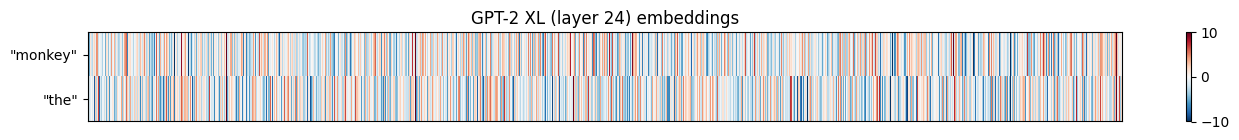

In [9]:
# Pick two words to compare (try changing these!)
word1, word2 = "monkey", "the"

# Build a word-level lookup: one embedding per word occurrence
words = df_contextual.groupby("word_idx").first()["word"].values

# Find the first occurrence of each word
idx1 = np.where(words == word1)[0][0]
idx2 = np.where(words == word2)[0][0]

emb1 = aligned_embeddings[idx1]
emb2 = aligned_embeddings[idx2]

# Stack into a 2×D matrix for imshow
matrix = np.stack([emb1, emb2])

# Symmetric color limits so 0 is white
vmax = 10  # max(abs(matrix.min()), abs(matrix.max())) # you can edit the value here to zoom in or out of the color range

fig, ax = plt.subplots(figsize=(14, 1.5))
im = ax.imshow(matrix, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax, interpolation="nearest")
ax.set_yticks([0, 1])
ax.set_yticklabels([f'"{word1}"', f'"{word2}"'])
ax.set_xticks([])
ax.set_title(f"GPT-2 XL (layer {layer}) embeddings")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

Remember these are contextual embeddings, so the same word will be represented differently depending on the context in which is occurs. Lets explore that briefly...

Found 6 occurrences of "how"


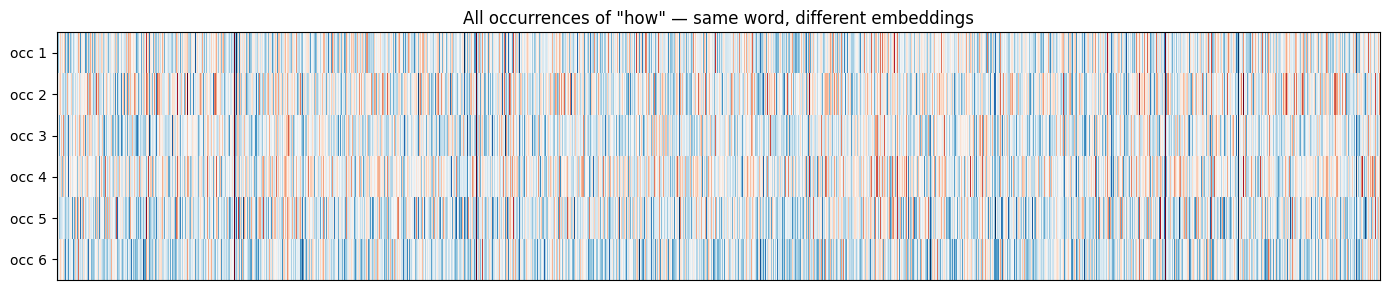

In [10]:

# Because GPT-2 is a contextual model, the same word gets a different
# embedding depending on the surrounding words. Let's see this in action.

# pick target word
target_word = "how"

# Find all occurrences of the target word
word_labels = df_contextual.groupby("word_idx").first()["word"].values
occurrences = np.where(word_labels == target_word)[0]

print(f'Found {len(occurrences)} occurrences of "{target_word}"')

# Stack embeddings into a matrix (n_occurrences × D)
embs = aligned_embeddings[occurrences]

# Symmetric color limits so 0 is white
vmax = 10 # np.max(np.abs(embs))

fig, ax = plt.subplots(figsize=(14, max(1.5, 0.5 * len(occurrences))))
ax.imshow(embs, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax, interpolation="nearest")
ax.set_yticks(range(len(occurrences)))
ax.set_yticklabels([f"occ {i+1}" for i in range(len(occurrences))])
ax.set_xticks([])
ax.set_title(f'All occurrences of "{target_word}" — same word, different embeddings')
plt.tight_layout()
plt.show()

## Load the neural data

Now let's load the preprocessed ECoG data. We will also load this in from [OpenNeuro.org](https://openneuro.org/). For this demo we will be using data from Subject 3, who has good electrode coverage.

In [11]:
file_path = BIDSPath(root=f"derivatives/ecogprep",
                    subject="03", task="podcast", datatype="ieeg", description="highgamma",
                    suffix="ieeg", extension=".fif")
print(f"File path within the dataset: {file_path}")

!wget -nc https://s3.amazonaws.com/openneuro.org/ds005574/$file_path
file_path = file_path.basename

raw = mne.io.read_raw_fif(file_path, verbose=False)
picks = mne.pick_channels_regexp(raw.ch_names, "LG[AB]*")
raw = raw.pick(picks)
raw

File path within the dataset: derivatives/ecogprep/sub-03/ieeg/sub-03_task-podcast_desc-highgamma_ieeg.fif
--2026-04-13 02:20:59--  https://s3.amazonaws.com/openneuro.org/ds005574/derivatives/ecogprep/sub-03/ieeg/sub-03_task-podcast_desc-highgamma_ieeg.fif
Resolving s3.amazonaws.com (s3.amazonaws.com)... 16.15.207.184, 16.15.212.132, 16.15.252.109, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|16.15.207.184|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 866371015 (826M) [biosig/fiff]
Saving to: ‘sub-03_task-podcast_desc-highgamma_ieeg.fif’

sub-03_task-podcast 100%[===================>] 826.24M  29.0MB/s    in 20s     

2026-04-13 02:21:20 (40.3 MB/s) - ‘sub-03_task-podcast_desc-highgamma_ieeg.fif’ saved [866371015/866371015]



<Raw | sub-03_task-podcast_desc-highgamma_ieeg.fif, 127 x 921600 (1800.0 s), ~187 KiB, data not loaded>

Next, we want to work out when the onset of each word is occuring in the neural recording. We do this by multiplying each word onset (currently in seconds) by the sampling rate of the neural recording. We create an events variable to store this in, with the first column marking the start of each word on the neural data.

In [12]:
events = np.zeros((len(df_word), 3), dtype=int)
events[:, 0] = (df_word.start * raw.info['sfreq']).astype(int)
events.shape

(5136, 3)

Next, we take advantage of MNE's tools for creating epochs around stimulus events. We will take a fixed-width window ranging from -2 seconds to +2 seconds relative to word onset. Since the sampling rate is 512 Hz (512 samples per second), we have 2049 datapoints per epoch. The ECoG data is a numpy array with shape: number of words * number of ECoG electrodes * number of lags.

In [13]:
epochs = mne.Epochs(
    raw,
    events,
    tmin=-2.0,
    tmax=2.0,
    baseline=None,
    proj=False,
    event_id=None,
    preload=True,
    event_repeated="merge",
)
print(f"Epochs object has a shape of: {epochs._data.shape}")

Not setting metadata
5136 matching events found
No baseline correction applied
Loading data for 5136 events and 2049 original time points ...


/tmp/ipykernel_714/3482921024.py:1: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs = mne.Epochs(


6 bad epochs dropped
Epochs object has a shape of: (5130, 127, 2049)


Now let's downsample the neural data to a temporal resolution of 32 Hz, which reduces the number of lags to 32 * 4 = 128. We're doing this here just to speed up the model fitting since there will be fewer datapoints to predict.

**Note: the following code chunk may take a few minutes to run.**

In [14]:
epochs = epochs.resample(sfreq=32, npad='auto', method='fft', window='hamming')
print(f"Epochs object has a shape of: {epochs._data.shape}")

Epochs object has a shape of: (5130, 127, 128)


Now let's quickly visualise the word-locked neural responses for a few electrodes. This will help us to get a sense of what the average neural response to words looks like!

In [15]:
# first lets print out all the electrode names to see what options we have
print(epochs.ch_names)


['LGA2', 'LGA3', 'LGA4', 'LGA5', 'LGA6', 'LGA7', 'LGA8', 'LGA9', 'LGA10', 'LGA11', 'LGA12', 'LGA13', 'LGA14', 'LGA15', 'LGA16', 'LGA17', 'LGA18', 'LGA19', 'LGA20', 'LGA21', 'LGA22', 'LGA23', 'LGA24', 'LGA25', 'LGA26', 'LGA27', 'LGA28', 'LGA29', 'LGA30', 'LGA31', 'LGA32', 'LGA33', 'LGA34', 'LGA35', 'LGA36', 'LGA37', 'LGA38', 'LGA39', 'LGA40', 'LGA41', 'LGA42', 'LGA43', 'LGA44', 'LGA45', 'LGA46', 'LGA47', 'LGA48', 'LGA49', 'LGA50', 'LGA51', 'LGA52', 'LGA53', 'LGA54', 'LGA55', 'LGA56', 'LGA57', 'LGA58', 'LGA59', 'LGA60', 'LGA61', 'LGA62', 'LGA63', 'LGA64', 'LGB65', 'LGB66', 'LGB67', 'LGB68', 'LGB69', 'LGB70', 'LGB71', 'LGB72', 'LGB73', 'LGB74', 'LGB75', 'LGB76', 'LGB77', 'LGB78', 'LGB79', 'LGB80', 'LGB81', 'LGB82', 'LGB83', 'LGB84', 'LGB85', 'LGB86', 'LGB87', 'LGB88', 'LGB89', 'LGB90', 'LGB91', 'LGB92', 'LGB93', 'LGB94', 'LGB95', 'LGB96', 'LGB97', 'LGB98', 'LGB99', 'LGB100', 'LGB101', 'LGB102', 'LGB103', 'LGB104', 'LGB105', 'LGB106', 'LGB107', 'LGB108', 'LGB109', 'LGB110', 'LGB111', 'LGB1

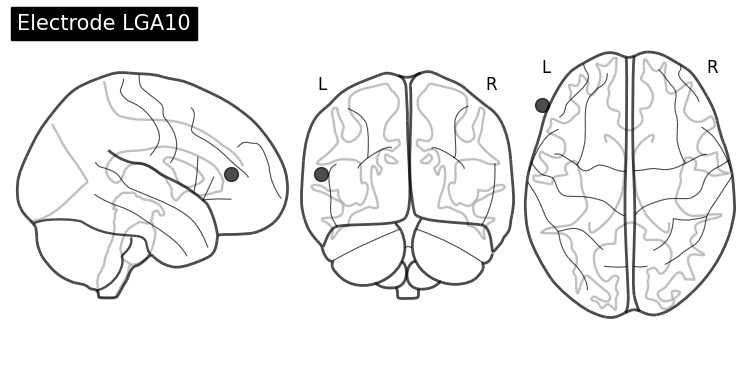

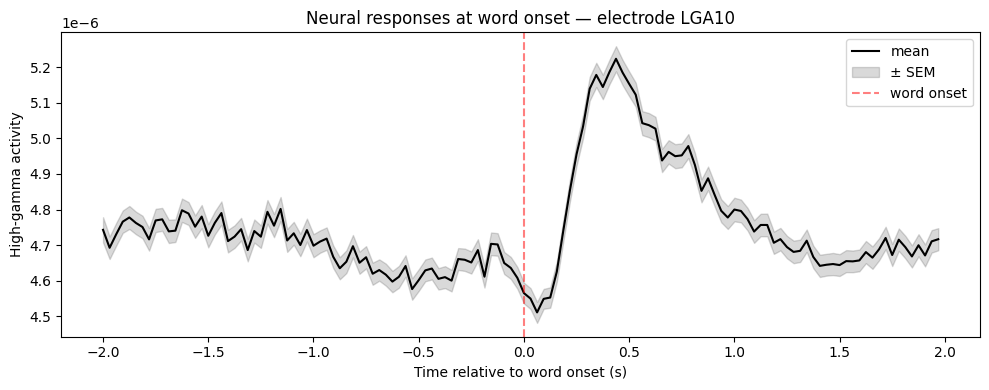

In [16]:

# now pick an electrode to inspect (try changing this!)

electrode = "LGA10"
ch_idx = epochs.ch_names.index(electrode)

# Get the epoch data for this electrode: (n_words, n_timepoints)
erp_data = epochs.get_data(copy=True)[:, ch_idx, :]
times = epochs.times  # time axis in seconds, 0 = word onset

# plot location of electrode:
ch2loc = {ch['ch_name']: ch['loc'][:3] for ch in raw.info['chs']}
pos = ch2loc[electrode] * 1000  # meters→mm scaling

plot_markers(
    [0],
    [pos],
    display_mode='ortho',
    title=f"Electrode {electrode}",
    colorbar = False

)
plt.show()

# plot mean and SEM of the neural response
fig, ax = plt.subplots(figsize=(10, 4))

mean_resp = erp_data.mean(axis=0)
sem_resp = erp_data.std(axis=0) / np.sqrt(erp_data.shape[0])
ax.plot(times, mean_resp, color="black", linewidth=1.5, label="mean")
ax.fill_between(times, mean_resp - sem_resp, mean_resp + sem_resp,
                color="black", alpha=0.15, label="± SEM")

ax.axvline(0, color="red", linestyle="--", alpha=0.5, label="word onset")
ax.set_xlabel("Time relative to word onset (s)")
ax.set_ylabel("High-gamma activity")
ax.set_title(f"Neural responses at word onset — electrode {electrode}")
ax.legend()
plt.tight_layout()
plt.show()

## Set up feature and brain data for modelling

Now we have both the features (word embeddings) and the ECoG data ready. We plan to fit encoding models at each electrode and for each lag relative to word onset, so we'll reshape our target matrix `Y` to horizontally stack both electrodes and lags along the second dimension.

In [17]:
epochs_data = epochs.get_data(copy=True)
epochs_data = epochs_data.reshape(len(epochs), -1)
print(f"ECoG data matrix shape: {epochs_data.shape}")

ECoG data matrix shape: (5130, 16256)


We will also align our features with the ECoG data.

In [19]:
# some bad epochs were dropped, so we also drop the corresponding words in out feature matrix

selected_df = df_word.iloc[epochs.selection]
averaged_embeddings = aligned_embeddings[epochs.selection]
print(averaged_embeddings.shape)

(5130, 1600)


We will change the float precision to float32 for all data to take advantage of the GPU memory and computational speed.

In [20]:
X = averaged_embeddings
Y = epochs_data

if "torch" in get_backend().__name__:
    X = X.astype(np.float32)
    Y = Y.astype(np.float32)

X.shape, Y.shape

((5130, 1600), (5130, 16256))

## Building the encoding model

Now, we will use ridge regression to estimate the encoding model. We create a model pipeline using `sklearn`, which includes a [StandardScaler](https://scikit-learn.org/dev/modules/generated/sklearn.preprocessing.StandardScaler.html) that standardizes the features (X), and a [RidgeCV](https://gallantlab.org/himalaya/_generated/himalaya.ridge.RidgeCV.html) model, which performs ridge regression with cross-validation over our specificed alpha values.

In [21]:
alphas = np.logspace(1, 10, 10) # specify alpha values (these control the strength of the regularisation in our ridge model)
inner_cv = KFold(n_splits=5, shuffle=False) # inner 5-fold cross-validation setup
model = make_pipeline(
    StandardScaler(), RidgeCV(alphas, fit_intercept=True, cv=inner_cv) # pipeline
)
model

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('ridgecv',
                 RidgeCV(alphas=array([1.e+01, 1.e+02, 1.e+03, 1.e+04, 1.e+05, 1.e+06, 1.e+07, 1.e+08,
       1.e+09, 1.e+10]),
                         cv=KFold(n_splits=5, random_state=None, shuffle=False),
                         fit_intercept=True))])

## Training and testing the encoding model

While `RidgeCV` contains an inner cross-validation setup to find the best alpha, we will also set up an outer cross-validation loop to evaluate our encoding model. Here, we will train on half of the data and evaluate on the other half. Within each fold, we will split the train and test dataset. Then we will standardize `Y` the same way we standardize `X` in the pipeline. We will then fit our model on the training dataset and use it to predict for the testing dataset. For evaluation, we will calculate correlation scores between `Y_preds`, the ECoG signal predicted by our model, and `Y_test`, the actual ECoG signal. The encoding model is trained and evaluated for each electrode and each lag.

In [22]:
epochs_shape = epochs._data.shape[1:] # number of electrodes * number of lags

def train_encoding(X, Y):

    corrs = [] # empty array to store correlation scores
    kfold = KFold(2, shuffle=False) # outer 2-fold cross-validation setup
    for train_index, test_index in kfold.split(X): # loop through folds

        # split train and test datasets
        X1_train, X1_test = X[train_index], X[test_index]
        Y_train, Y_test = Y[train_index], Y[test_index]

        # standardize Y
        scaler = StandardScaler()
        Y_train = scaler.fit_transform(Y_train)
        Y_test = scaler.transform(Y_test)

        model.fit(X1_train, Y_train) # fit pipeline with transforms and ridge estimator
        Y_preds = model.predict(X1_test) # Use trained model to predict on test set
        corr = correlation_score(Y_test, Y_preds).reshape(epochs_shape) # compute correlation score and reshape back to n_electrodes x n_lags

        if "torch" in get_backend().__name__: # if using gpu, transform tensor back to numpy
            corr = corr.numpy(force=True)

        corrs.append(corr) # append fold correlation results to final results
    return np.stack(corrs)

# set_backend("torch") # resort to torch or numpy if cuda out of memory
corrs_embedding = train_encoding(X, Y)
print(f"Encoding model scores matrix shape: {corrs_embedding.shape}")

Encoding model scores matrix shape: (2, 127, 128)


## Plotting encoding performance

We trained and evaluated many encoding models. We have 127 electrodes with 128 time lags at each. On top of that we split the podcast into two 15-minute chunks to train on one half and test on the other. Thus, we have correlations for each of these in one array. Below, we will summarize these results in two ways: spatially and temporally.

First we summarize spatially by averaging over all electrodes and splits and looking at the average temporal pattern of correlations. We notice that encoding performance increases after word onset and is lower near ± 2 seconds.

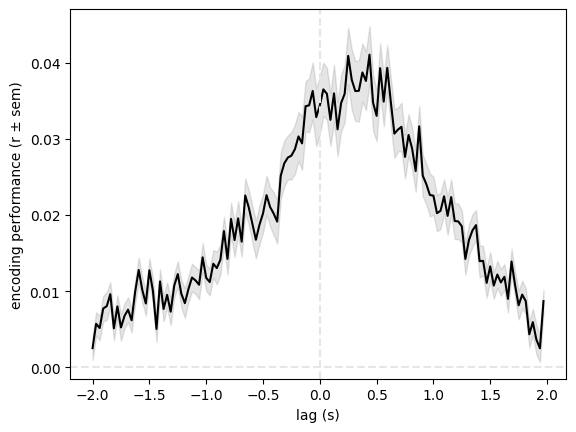

In [23]:
lags = np.arange(-2 * 512, 2 * 512, 16) / 512 # specify the lags
mean = corrs_embedding.mean((0,1))
err = corrs_embedding.std((0,1)) / np.sqrt(np.prod(corrs_embedding.shape[:2]))

fig, ax = plt.subplots()
ax.plot(lags, mean, color='black')
ax.fill_between(lags, mean - err, mean + err, alpha=0.1, color='black')
ax.set_xlabel("lag (s)")
ax.set_ylabel("encoding performance (r ± sem)")
ax.axvline(0, c=(.9, .9, .9), ls="--")
ax.axhline(0, c=(.9, .9, .9), ls="--")
fig.show()

Next we summarize temporally by selecting the maximum correlation across lags per electrode. Now that we have one correlation per electrode, we plot the results on the brain.

Coordinate matrix shape:  (127, 3)


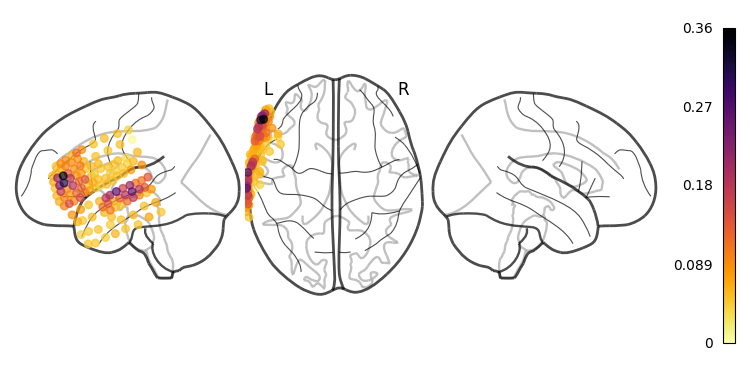

In [24]:
values = corrs_embedding.mean(0).max(-1)

ch2loc = {ch['ch_name']: ch['loc'][:3] for ch in raw.info['chs']}
coords = np.vstack([ch2loc[ch] for ch in raw.info['ch_names']])
coords *= 1000  # nilearn likes to plot in meters, not mm
print("Coordinate matrix shape: ", coords.shape)

order = values.argsort()
plot_markers(values[order], coords[order],
             node_size=30, display_mode='lzr',
             node_vmin=0, node_cmap='inferno_r', colorbar=True)
plt.show()

# Interpreting encoding model results
We've now successfully fit a model to predict neural responses to speech using word embeddings from LLMs! But this is where the tricky work really begins...

When we find that LLM embeddings can predict brain activity, it's tempting to conclude that the two systems represent language/meaning in similar ways. But before making that leap, we need to ask *why* the mapping works. The answer might be genuinely interesting... perhaps LLMs and brains converge on similar semantic structures! But it could also reflect less interesting confounds. For instance, LLMs may encode word frequency information in their embeddings, and the brain may respond differently to rare versus common words. A successful mapping between the two might partly be picking up on this shared sensitivity to frequency, rather than anything deeper about how meaning is represented. The same logic applies to other surface-level features like word length or acoustic properties. Disentangling these explanations is essential: a good brain-to-LLM mapping tells us that something is shared, but not necessarily what that is!

# Could word frequency be important?

For the remainder of this tutorial, let's extract word frequency to have a look at whether neural responses differ for rare vs common words! We can do this using the wordfreq package (which we loaded at the start) which counts how often each word appears across a large collection of text sources and then divides each word's count by the total number of words to get a probability. The word "the" makes up ~5% of all English text and would have a word frequency of ~0.05, whereas the word "mongoose" has a word frequency value of 4.68e-07.

Let's construct a function to extract word frequencies, and have a quick look at the frequencies we extract for the current stimulus:

In [31]:
from wordfreq import word_frequency

# uncomment to look at the word frequency examples yourself!
#print(word_frequency, 'the', 'en')
#print(word_frequency('mongoose', 'en'))

def get_freq(word, lang="en"):
    # Strip punctuation so "middle." matches "middle"
    clean = word.strip(".,!?;:\"'()-").lower()
    return word_frequency(clean, lang)

df_word["word_freq"] = df_word["word"].apply(get_freq)

print("Word frequency stats:")
print(df_word["word_freq"].describe())
print("\nSample rows:")
print(df_word[["word", "word_freq"]].head(10))


Word frequency stats:
count    5136.000000
mean        0.007861
std         0.013813
min         0.000000
25%         0.000089
50%         0.001100
75%         0.008910
max         0.053700
Name: word_freq, dtype: float64

Sample rows:
             word  word_freq
word_idx                    
0             Act   0.000200
1            one,   0.002950
2          monkey   0.000012
3              in   0.018600
4             the   0.053700
5         middle.   0.000151
6              So   0.003310
7         there's   0.000347
8            some   0.001580
9          places   0.000107


Now we can set a mask for word frequency subgroups. We are most interested in 25% of words that have the lowest word frequency and the 25% with the highest word frequency:

In [27]:

q25, q75 = df_word["word_freq"].quantile([0.25, 0.75])
low_freq  = df_word.loc[df_word["word_freq"] <= q25, "word_freq"]
high_freq = df_word.loc[df_word["word_freq"] >= q75, "word_freq"]


Let's visually confirm whether the low and high frequency words are indeed different from each other, by creating a boxplot:

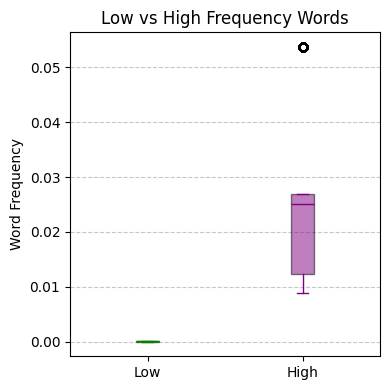

In [28]:

fig, ax = plt.subplots(figsize=(4, 4))
bp = ax.boxplot([low_freq, high_freq], tick_labels=["Low", "High"], patch_artist=True)

colors = ['green', 'purple']
for i, color in enumerate(colors):
    bp['boxes'][i].set_facecolor(color)
    bp['boxes'][i].set_alpha(0.5)
    bp['medians'][i].set_color(color)
    bp['whiskers'][2*i].set_color(color)
    bp['whiskers'][2*i+1].set_color(color)
    bp['caps'][2*i].set_color(color)
    bp['caps'][2*i+1].set_color(color)

ax.set_ylabel("Word Frequency")
ax.set_title("Low vs High Frequency Words")
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


Now lets look at the average neural response, for the two word frequency groups!

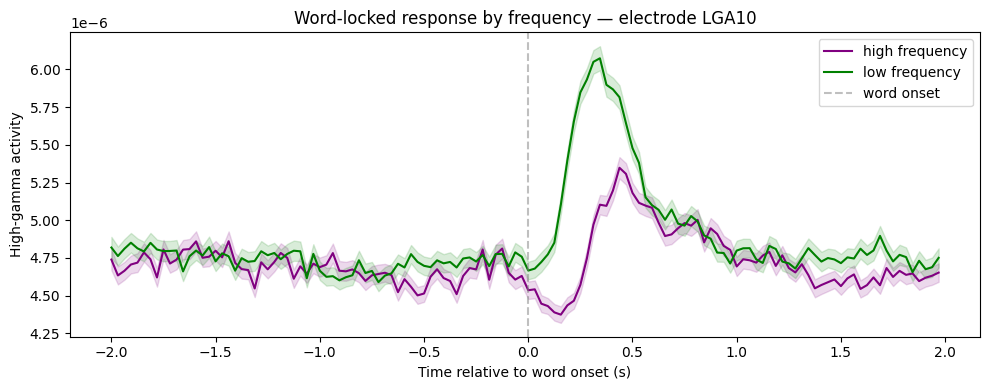

In [29]:

electrode = "LGA10"
ch_idx = epochs.ch_names.index(electrode)

erp_data = epochs.get_data(copy=True)[:, ch_idx, :]
times = epochs.times

# Split by word frequency using kept epochs
kept_idx = epochs.selection
freqs = df_word.iloc[kept_idx]["word_freq"].values
high_freq_mask = freqs >= q75
low_freq_mask  = freqs <= q25

fig, ax = plt.subplots(figsize=(10, 4))

for mask, label, color in [(high_freq_mask, "high frequency", "purple"),
                            (low_freq_mask, "low frequency", "green")]:
    mean_resp = erp_data[mask].mean(axis=0)
    sem_resp = erp_data[mask].std(axis=0) / np.sqrt(mask.sum())
    ax.plot(times, mean_resp, color=color, linewidth=1.5, label=label)
    ax.fill_between(times, mean_resp - sem_resp, mean_resp + sem_resp,
                    color=color, alpha=0.15)

ax.axvline(0, color="grey", linestyle="--", alpha=0.5, label="word onset")
ax.set_xlabel("Time relative to word onset (s)")
ax.set_ylabel("High-gamma activity")
ax.set_title(f"Word-locked response by frequency — electrode {electrode}")
ax.legend()
plt.tight_layout()
plt.show()


So we can clearly see that at this electrode, low frequency words tend to evoke a stronger response than high frequency words!

To get a crude sense of whether LLM embeddings differ across low and high frequency words we can look at the average embeddings for these groups.

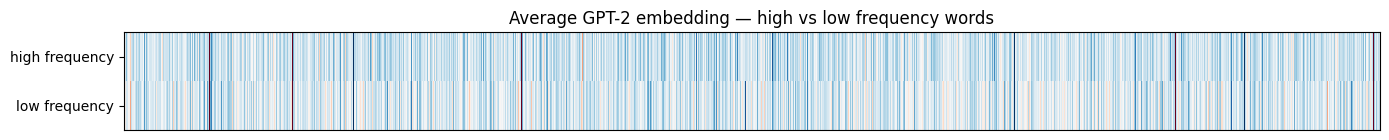

In [32]:
# split embeddings by word frequency

kept_idx = epochs.selection  # indices of epochs that survived rejection
high_freq_mask = df_word.iloc[kept_idx]["word_freq"].values >= q75
low_freq_mask  = df_word.iloc[kept_idx]["word_freq"].values <= q25

high_freq_emb = averaged_embeddings[high_freq_mask].mean(axis=0)
low_freq_emb  = averaged_embeddings[low_freq_mask].mean(axis=0)

matrix = np.stack([high_freq_emb, low_freq_emb])
vmax = 5

fig, ax = plt.subplots(figsize=(14, 1.5))
ax.imshow(matrix, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax, interpolation="nearest")
ax.set_yticks([0, 1])
ax.set_yticklabels(["high frequency", "low frequency"])
ax.set_xticks([])
ax.set_title("Average GPT-2 embedding — high vs low frequency words")
plt.tight_layout()
plt.show()

We tend to see differences on average between these groups... suggesting it may be possible that explain some of the mapping we are seeing as being due to word frequency effects. To properly test this however, we would need to build a new encoding model which includes word frequency in addition to LLM embeddings, to control for this potential confound.